In [1]:
# instal required libraries
pip install tensorflow matplotlib pillow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [1]:
# Set Dataset Path
dataset_path = r"D:\cropguard\DATAASETT"

In [2]:
# Create Image Generator (Auto Split + Augmentation)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.3,
    shear_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

In [3]:
# Load Training Data
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 2398 images belonging to 8 classes.


In [4]:
# Load Validation Data
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 596 images belonging to 8 classes.


In [13]:
print(train_data.class_indices)

{'Banana_yellow_Sigatoka': 0, 'Tomato_BacterialL_spot': 1, 'banana_pseudostem_weevil_damage': 2, 'brinjal_Wet Rot': 3, 'cinnamon_StripeCanker': 4, 'healthy': 5, 'mango_Anthracnose': 6, 'mango_powder_mildew': 7}


In [14]:
train_data.class_indices

{'Banana_yellow_Sigatoka': 0,
 'Tomato_BacterialL_spot': 1,
 'banana_pseudostem_weevil_damage': 2,
 'brinjal_Wet Rot': 3,
 'cinnamon_StripeCanker': 4,
 'healthy': 5,
 'mango_Anthracnose': 6,
 'mango_powder_mildew': 7}

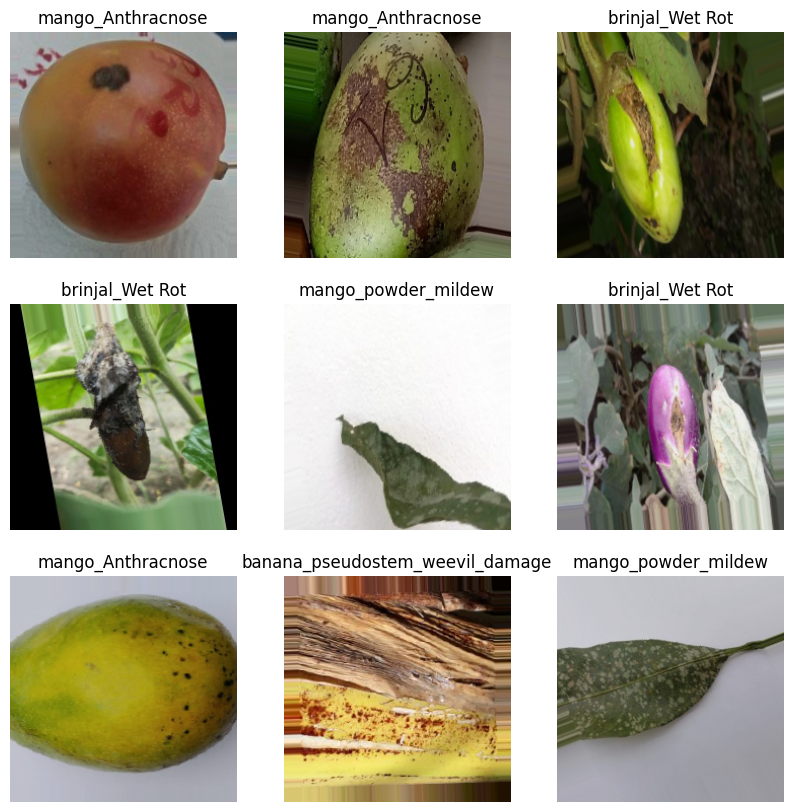

In [5]:
# load and see dataset
import matplotlib.pyplot as plt

# Get one batch
images, labels = next(train_data)

# Show first 9 images
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(list(train_data.class_indices.keys())[labels[i].argmax()])
    plt.axis('off')

plt.show()

In [9]:
# Check Classes
print(train_data.class_indices)
print(train_data.samples)
print(val_data.samples)

{'Banana_yellow_Sigatoka': 0, 'Tomato_BacterialL_spot': 1, 'banana_pseudostem_weevil_damage': 2, 'brinjal_Wet Rot': 3, 'cinnamon_StripeCanker': 4, 'healthy': 5, 'mango_Anthracnose': 6, 'mango_powder_mildew': 7}
2398
596


In [10]:
print("Total training images:", train_data.samples)
print("Classes:", train_data.num_classes)

Total training images: 2398
Classes: 8


In [11]:
# load Resnet-50 model 
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [12]:
# freeze layers
for layer in base_model.layers:
    layer.trainable = False

In [13]:
# build model
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.6),
    layers.Dense(train_data.num_classes, activation='softmax')
])

In [14]:
# compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
# add callbacks 
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)

In [16]:
# train model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 607s 7s/step - accuracy: 0.5142 - loss: 1.4443 - val_accuracy: 0.1409 - val_loss: 2.8101 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 569s 8s/step - accuracy: 0.6476 - loss: 1.0333 - val_accuracy: 0.1409 - val_loss: 2.3840 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 572s 8s/step - accuracy: 0.6922 - loss: 0.9180 - val_accuracy: 0.2097 - val_loss: 1.8791 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 530s 7s/step - accuracy: 0.7064 - loss: 0.8517 - val_accuracy: 0.5117 - val_loss: 1.4307 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 528s 7s/step - accuracy: 0.7389 - loss: 0.7627 - val_accuracy: 0.7450 - val_loss: 1.1283 - learning_rate: 0.0010
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 360s 5s/step - accuracy: 0.7611 - loss: 0.7192 - val_accuracy: 0.7819 - val_loss: 0.9457 - learning_rate: 0.0010
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 330s 4s/step - accuracy: 0.7665 - loss: 0.6871 - val_acc

In [17]:
# save model

model.save("cropguard_model.keras")

In [18]:
print("Final Train Accuracy:", history.history['accuracy'][-1])
print("Final Val Accuracy:", history.history['val_accuracy'][-1])

Final Train Accuracy: 0.8085904717445374
Final Val Accuracy: 0.823825478553772


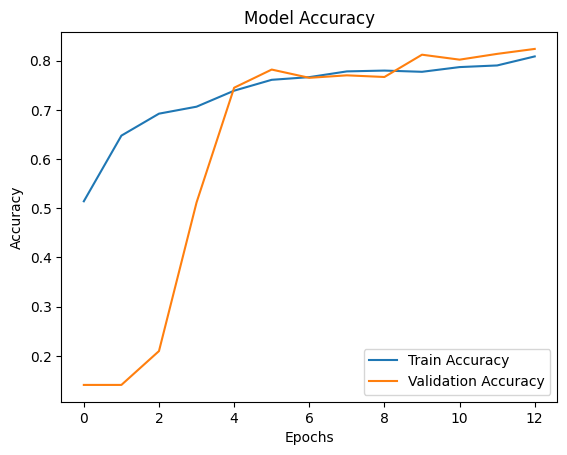

In [19]:
# accuracy graph
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

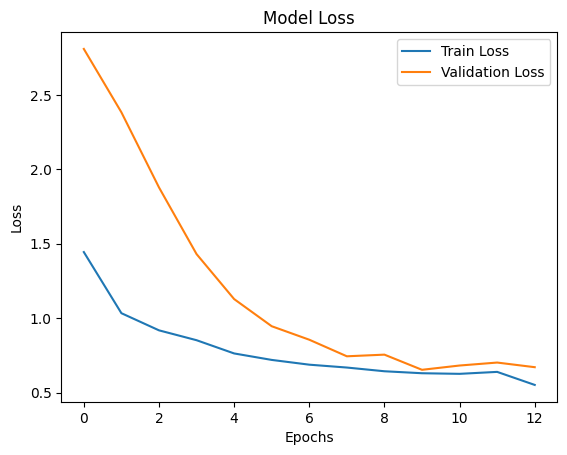

In [20]:
# loss graph

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [21]:
# evaluate data
model.evaluate(val_data)

19/19 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.7886 - loss: 0.6909


[0.6908608078956604, 0.7885906100273132]

In [22]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

class_names = list(val_data.class_indices.keys())

In [12]:
from tensorflow.keras.models import load_model

model = load_model("cropguard_model.keras")

In [11]:
from sklearn.metrics import classification_report
import numpy as np

# get one batch (fast and safe)
images, labels = next(iter(val_data))

# predictions
y_pred = model.predict(images)
y_pred_classes = np.argmax(y_pred, axis=1)

# true labels (use this if labels are one-hot encoded)
y_true = np.argmax(labels, axis=1)

# report
print(classification_report(y_true, y_pred_classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.83      0.71      0.77         7
           2       1.00      0.80      0.89         5
           3       0.57      1.00      0.73         4
           5       1.00      0.50      0.67         2
           6       1.00      1.00      1.00         5
           7       1.00      1.00      1.00         3

    accuracy                           0.84        32
   macro avg       0.89      0.84      0.84        32
weighted avg       0.88      0.84      0.85        32



1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


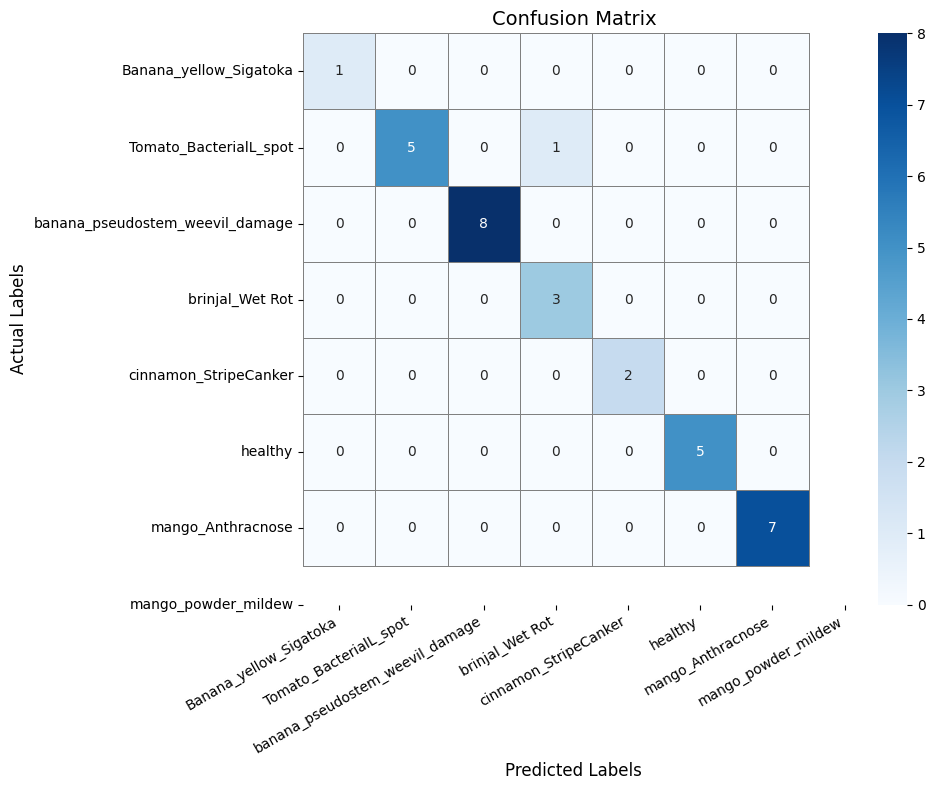

In [17]:
# confusion matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# batch prediction (fast)
images, labels = next(iter(val_data))

y_pred = model.predict(images)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(labels, axis=1)

class_names = list(val_data.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))  # bigger figure = cleaner

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,   # adds grid lines
    linecolor='gray',
    cbar=True
)

plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("Actual Labels", fontsize=12)

plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()  # fixes overlapping
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
🌱 Predicted Disease: mango_powder_mildew
📊 Confidence Score: 99.59%


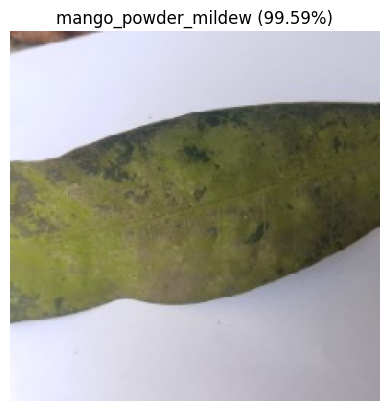

In [18]:
# test input image

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# class names (important)
class_names = list(val_data.class_indices.keys())

# image path (change this)
img_path = r"D:\cropguard\test\powdery_mildew.jpg"

# load image
img = image.load_img(img_path, target_size=(224, 224))

# convert to array
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# prediction
pred = model.predict(img_array)

# results
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

print("🌱 Predicted Disease:", predicted_class)
print("📊 Confidence Score: {:.2f}%".format(confidence))

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
🌱 Predicted Disease: Tomato_BacterialL_spot
📊 Confidence Score: 94.94%


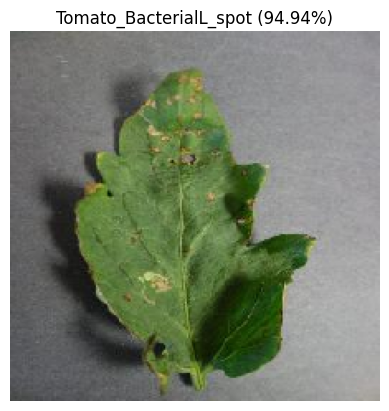

In [19]:
# test input image

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# class names (important)
class_names = list(val_data.class_indices.keys())

# image path (change this)
img_path = r"D:\cropguard\test\tomato_bs (38).JPG"

# load image
img = image.load_img(img_path, target_size=(224, 224))

# convert to array
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# prediction
pred = model.predict(img_array)

# results
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

print("🌱 Predicted Disease:", predicted_class)
print("📊 Confidence Score: {:.2f}%".format(confidence))

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
🌱 Predicted Disease: banana_pseudostem_weevil_damage
📊 Confidence Score: 82.27%


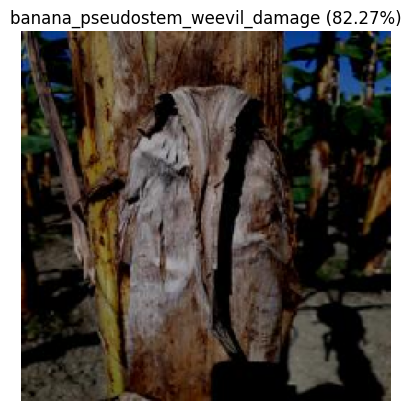

In [20]:
# test input image

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# class names (important)
class_names = list(val_data.class_indices.keys())

# image path (change this)
img_path = r"D:\cropguard\test\banana-weevil.jpg"

# load image
img = image.load_img(img_path, target_size=(224, 224))

# convert to array
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# prediction
pred = model.predict(img_array)

# results
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

print("🌱 Predicted Disease:", predicted_class)
print("📊 Confidence Score: {:.2f}%".format(confidence))

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
🌱 Predicted Disease: Banana_yellow_Sigatoka
📊 Confidence Score: 38.83%


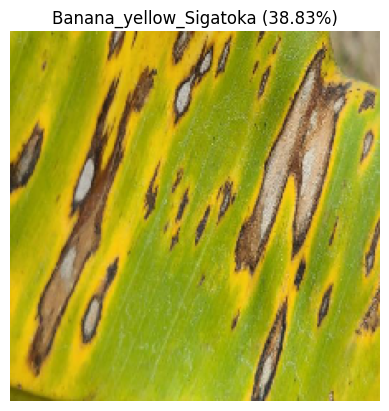

In [21]:
# test input image

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# class names (important)
class_names = list(val_data.class_indices.keys())

# image path (change this)
img_path = r"D:\cropguard\test\Yellow Sigatoka.jpg"

# load image
img = image.load_img(img_path, target_size=(224, 224))

# convert to array
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# prediction
pred = model.predict(img_array)

# results
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

print("🌱 Predicted Disease:", predicted_class)
print("📊 Confidence Score: {:.2f}%".format(confidence))

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
🌱 Predicted Disease: brinjal_Wet Rot
📊 Confidence Score: 62.86%


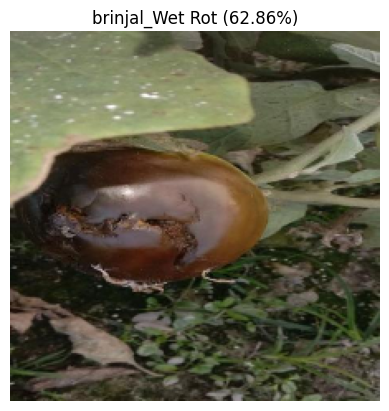

In [22]:
# test input image

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# class names (important)
class_names = list(val_data.class_indices.keys())

# image path (change this)
img_path = r"D:\cropguard\test\brinjaall.jpg"

# load image
img = image.load_img(img_path, target_size=(224, 224))

# convert to array
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# prediction
pred = model.predict(img_array)

# results
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

print("🌱 Predicted Disease:", predicted_class)
print("📊 Confidence Score: {:.2f}%".format(confidence))

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
🌱 Predicted Disease: cinnamon_StripeCanker
📊 Confidence Score: 88.33%


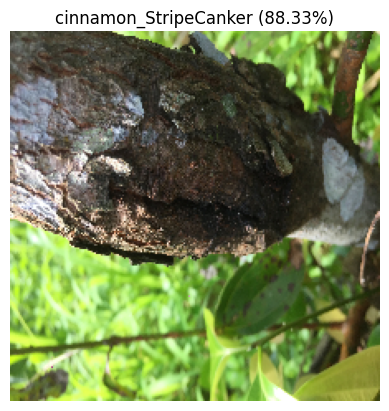

In [24]:
# test input image

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# class names (important)
class_names = list(val_data.class_indices.keys())

# image path (change this)
img_path = r"D:\cropguard\test\IMG_1548.JPG"

# load image
img = image.load_img(img_path, target_size=(224, 224))

# convert to array
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# prediction
pred = model.predict(img_array)

# results
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

print("🌱 Predicted Disease:", predicted_class)
print("📊 Confidence Score: {:.2f}%".format(confidence))

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
🌱 Predicted Disease: mango_Anthracnose
📊 Confidence Score: 46.59%


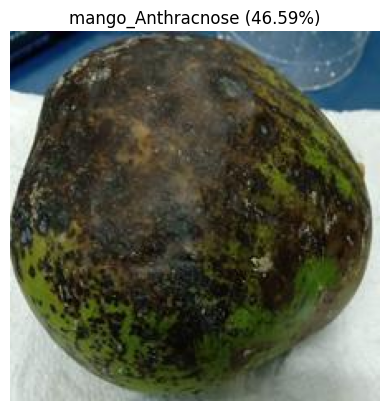

In [26]:
# test input image

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# class names (important)
class_names = list(val_data.class_indices.keys())

# image path (change this)
img_path = r"D:\cropguard\test\anthracnose_016.jpg"

# load image
img = image.load_img(img_path, target_size=(224, 224))

# convert to array
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# prediction
pred = model.predict(img_array)

# results
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

print("🌱 Predicted Disease:", predicted_class)
print("📊 Confidence Score: {:.2f}%".format(confidence))

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
🌱 Predicted Disease: healthy
📊 Confidence Score: 74.78%


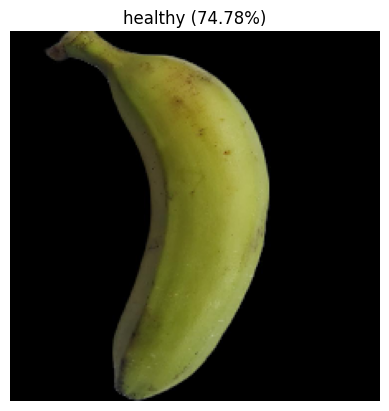

In [15]:
# test input image

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# class names (important)
class_names = list(val_data.class_indices.keys())

# image path (change this)
img_path = r"D:\cropguard\test\h1(30).jpg"

# load image
img = image.load_img(img_path, target_size=(224, 224))

# convert to array
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# prediction
pred = model.predict(img_array)

# results
predicted_class = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

print("🌱 Predicted Disease:", predicted_class)
print("📊 Confidence Score: {:.2f}%".format(confidence))

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()